# Text Analysis Pipeline_2

## Overview

This project will implement two topic modeling pipelines:

- **Pipeline_1:** CountVectorizer + Latent Semantic Analysis (TruncatedSVD)
- **Pipeline_2:** TfidfVectorizer + Latent Dirichlet Allocation (LDA)
  
**Pipeline_2: Latent Dirichlet Allocation (LDA) Using TfidfVectorizer (TF-IDF)**

This pipeline will implement the second topic extraction model on the same municipal complaints dataset.

The text cleaning, tokenization, and stopword removal were already performed in Pipeline_1, so these steps are not repeated here. Instead, this pipeline will import the prepared file `preprocessed_complaints.csv`, which was produced in Pipeline_1 after cleaning the dataset.

This file will be used as the input dataset for this pipeline.

**Shared Preprocessing Between the Two Pipelines**

As shown in the project's conception (Phase 1) workflow chart, the cleaning step is shared between both pipelines before the pipeline branches. Loading the same prepared file in both pipelines guarantees that they work on identical data. Therefore, differences in the later results come from the two different modeling approaches rather than from differences in the input dataset.

**Steps Implemented in This Pipeline**

The following steps will be implemented in Pipeline_2:

- Importing the libraries and classes needed for this pipeline.
- Importing the `preprocessed_complaints.csv` file from Pipeline_1.
- Constructing the TF-IDF matrix from the preprocessed complaint data.
- Fitting the LDA model to the TF-IDF matrix.
- Calculating coherence scores to determine the optimal number of topics (`k`).
- Visualizing the coherence scores.
- Applying the selected number of topics to the final LDA model.
- Observing and interpreting the extracted topics.
- Calculating the topic prevalence for each topic.
- Ranking the topics based on their prevalence.
- Summarizing the Pipeline_2 findings.
- Comparing the findings of Pipeline_1 and Pipeline_2.


### Step 1 : Importing the Libraries and Classes Needed for This Pipeline

This pipeline requires fewer libraries than Pipeline_1 because the text cleaning and preprocessing steps were already performed in Pipeline_1.

The preprocessed data will be imported from the file `preprocessed_complaints.csv`, which was created in Pipeline_1.



In [2]:
# Block 1

import pandas as pd
# Loads the pandas library into memory and gives it the short nickname 'pd' for easier reference in the code lines.
# Pandas is used here to load the already cleaned and preprocessed municipal complaints dataset 'preprocessed_complaints.csv'.

from sklearn.feature_extraction.text import TfidfVectorizer
# 'TfidfVectorizer' is a class from the sklearn.feature_extraction.text module.
# Builds the TF-IDF document-term matrix for this pipeline.
# Unlike the 'CountVectorizer' class used in pipeline_1, which counts raw word occurrences, 
# 'TfidfVectorizer' weights each word by how frequent it is in one single complaint text
# compared to how frequent it is across the whole corpus.

from sklearn.decomposition import LatentDirichletAllocation
# 'LatentDirichletAllocation' is a class from the 'sklearn.decomposition' module.
# Performs Latent Dirichlet Allocation (LDA) on the TF-IDF matrix/document-term matrix.
# LDA is a probabilistic model that treats each complaint as a mixture of topics, 
# and each topic as a distribution over words.

from gensim.corpora import Dictionary
# 'Dictionary' is a class from the 'gensim.corpora' module.
# It converts the tokenized complaint texts into a dictionary format, which is a mapping of unique words to their
# corresponding integer IDs.
# It is required by gensim's 'CoherenceModel' class to compute the coherence score for the topics generated by (LDA) model.

from gensim.models import CoherenceModel
# 'CoherenceModel' is a class from the 'gensim.models' module.
# It computes the coherence score for the candidate numbers of topics (k). So, the optimal (k) topics for this 
# LDA model is chosen based on the evidence, not picked up personally. 
# This coherence score process will measure the semantic similarity between the words in each topic.

import matplotlib.pyplot as plt
# 'matplotlib.pyplot' is a module that provides a set of functions for plotting graphs.
# It is used here to visualize the coherence scores as a plot graph.
# This step will make the process more visual and easier to understand what is going on.
# The x-axis will represent the number of topics.
# The y-axis will represent the coherence score, helping to visually identify the optimal number of topics to pick up.

from IPython.display import display, Markdown
from IPython.display import display, HTML
# These two libraries are imported just for displaying results' purposes.





### Step 2 : Load the Preprocessed Complaint Text

Importing the 'preprocessed_complaints.csv' file from the previous pipeline_1.
The complaint text used in this pipeline was already cleaned in pipeline_1.
There, the raw 'issue_descriptioin' column was loaded from 'municipal_complaints_training_dataset.csv' file.
Duplicate complaints were removed, and the remaining 447 complaints were cleaned through lowercasing, punctuation
removal, toekenization, lemmatization, and stopword removal.
The result was saved to 'preprocessed_complaints.csv' file.

Load the 'preprocessed_complaints.csv' file from the previous pipeline_1:



In [3]:
# Block 2

preprocessed_complaints = pd.read_csv('preprocessed_complaints.csv')
# 'pd.read_csv()' reads the already cleaned complaint texts from the 'preprocessed_complaints.csv' file.
# and loads it into a pandas DataFrame object called 'preprocessed_complaints'.

display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown(f"**Number of preprocessed complaints: {preprocessed_complaints.shape[0]}**"))
# 'shape[0]' returns the number of rows in this DataFrame.This will check confirm that the number of rows is 447.

cleaned_text = preprocessed_complaints['cleaned_text']
# Select the 'cleaned_text' column, and store it in a separate variable called 'cleaned_text'.
# This variable holds all cleaned complaint text rows. 

cleaned_tokens = cleaned_text.apply(lambda text: text.split())
# 'lambda' is a function that will create within each row a list of its individual words.
# This step is needed later by gensim 'CoherenceModel', which expects each complaint row
# to be a list of separated tokens (not as one joined string).

display(Markdown(f"**First 5 rows of cleaned text:**"))
display(cleaned_text.head())
# '.head()' returns the first 5 rows of the DataFrame.


display(Markdown(f"**First 5 rows of cleaned tokens:**"))
display(cleaned_tokens.head())
# Also here we will display the first 5 complaint rows as a visual check to see if the splitting is working properly.

<h3>The output of this block is:</h3>

**Number of preprocessed complaints: 447**

**First 5 rows of cleaned text:**

0    unauthorized late night party amplified sound ...
1    deep pothole near bus stop making dangerous co...
2    construction crew starting work way loud viola...
3    urgent significant water leak near school entr...
4    someone please fix small pothole getting deepe...
Name: cleaned_text, dtype: str

**First 5 rows of cleaned tokens:**

0    [unauthorized, late, night, party, amplified, ...
1    [deep, pothole, near, bus, stop, making, dange...
2    [construction, crew, starting, work, way, loud...
3    [urgent, significant, water, leak, near, schoo...
4    [someone, please, fix, small, pothole, getting...
Name: cleaned_text, dtype: object


### Step 3 : Constructing the TF-IDF/Document-Term Matrix

The next step is to convert the 'preprocessed_complaints.csv' file into a numeric representation
using 'TfidfVectorizer' class. 
Unlike the 'CountVectorizer' class in pipeline_1, which counts raw word occurrences, 
'TfidifVectorizer' weights each word by combining two measures:
- How frequent the word is in one single complaint text (term frequency).
- How rare the word is across the whole corpus (inverse document frequency).
As a result, words that appear in almost every complaint receive a lower weight, 
while words that are more distinctive to a smaller number of complaints receive a higher weight.

This produces the TF-IDF matrix: each row represents one complaint text,
each column represents one unique word/term from the vocabulary,
and each cell contains TF-IDF's weight of the word in the complaint text.
Instead of a raw count, the TF-IDF weight is a normalized value between 0 and 1.

Later, this resulting matrix will be fed as input to the LDA model.



In [4]:

# Block 3

tfidf_vectorizer = TfidfVectorizer()
# Initialize the 'TfidfVectorizer' class with the 'fit_transform' method.
# This will learn the vocabulary from the 'cleaned_text' column and produce the TF-IDF matrix.

tfidf_matrix = tfidf_vectorizer.fit_transform(cleaned_text)
# 'tfidf_vectorizer.fit_transform(Cleaned_text)' returns the resulted TF-IDF matrix in 'tfidf_matrix'.

terms = tfidf_vectorizer.get_feature_names_out()
# '.get_feature_names_out()' retrieves the vocabulary terms learned by 'TfidfVectorizer'.
# Needed later to translate topic word indices back into their corresponding terms/words. The same way 'terms' 
# was used in pipeline_1.

display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown(f"**Shape of the TF-IDF matrix (document, vocabulary size): {tfidf_matrix.shape}**"))
# 'tfidf_matrix.shape' returns the shape of the TF-IDF matrix, which is (447, 10,000).

display(Markdown(f"**Number of unique terms in the vocabulary: {len(terms)}**"))
# 'len()' returns the number of unique terms in the vocabulary.
# This will check and confirm that the number of unique terms is 10,000.

display(Markdown(f"**Example of vocabulary terms: {terms[:10]}**"))
# 'terms[:10]' returns the first 10 terms in the vocabulary.
# This will check confirm that the vocabulary contains the expected 10,000 terms.



<h3>The output of this block is:</h3>

**Shape of the TF-IDF matrix (document, vocabulary size): (447, 747)**

**Number of unique terms in the vocabulary: 747**

**Example of vocabulary terms: ['abandoned' 'access' 'accident' 'accumulating' 'across' 'address'
 'adjacent' 'affect' 'affecting' 'afraid']**


### Step 4 : Fitting the LDA Model to the TF-IDF Matrix

With the TF-IDF document-term matrix built, Latent Dirichlet Allocation (LDA)
will now be used to extract latent topics from it. 
This is done using the 'LatentDirichletAllocation' class from the 'sklearn.decomposition' module.
Unlike the 'TruncatedSVD' class used in pipeline_1, which performs a mathematical dimensionality reduction,
'LatentDirichletAllocation' model: it treats each complaint as a mixture of topics, and each topic 
as a distribution over words, then estimates these distributions from the patterns of word co-occurrences in the corpus.

'LatentDirichletAllocation' also requires the number of topics ('n_components') to be estimated as in
pipeline_1.
A placeholder value is used now only to demonstrate how the method works and what its output look like.
The actual optimal number (k) of topics will be determined later in the next step.



In [5]:
# Block 4

lda_model = LatentDirichletAllocation(n_components=5, learning_method = 'batch', random_state=42)
# Initialize the 'LatentDirichletAllocation' class with the 'n_components=5', a placeholder value(5)
# is used only to demonstrate the method.
# 'random_state=42' is a conventional value used to set the random seed for reproducibility (no changes occur to the result
# in every execution of the code).

lda_matrix = lda_model.fit_transform(tfidf_matrix)
# 'lda_model.fit_transform(tfidf_matrix)' returns the resulted document-topic matrix in 'lda_matrix'.
# Each cell [i, j] in the matrix holds the probability of the j-th topic for the i-th document.

display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown(f"**Shape of the LDA-reduced matrix (document, topics): {lda_matrix.shape}**"))
# 'lda_matrix.shape' returns (number of complaints, number of topics),
# showing that each complaint is now represented as a vector of 5 values.

document_distribution = " | ".join(f"{value:.4f}" for value in lda_matrix[0])

display(Markdown(f"**Example of document-topic distribution (first complaint): [{document_distribution}]**"))
# Unlike LSA, the LDA's output values for each document form a probability distribution over topics, 
# This means that they sum to 1; this displayed example shows how much the first complaint belongs
# to each of the 5 placeholder topics.


<h3>The output of this block is:</h3>

**Shape of the LDA-reduced matrix (document, topics): (447, 5)**

**Example of document-topic distribution (first complaint): [0.0513 | 0.0515 | 0.0568 | 0.0511 | 0.7893]**


### Step 5 : Determine the Optimal Number of Topics (k) Using Coherence Scores

As in Pipeline_1, we do not choose the number of topics (k) arbitrarily.

The `optimal(k)` is determined using topic coherence scores, calculated with 'gensim.models. CoherenceModel',
Following the method specified in the project plan.
Based on the volume of the dataset (447 complaints), then the search space in the coherence scores
was limited to the first range of k= 2 -10 to test the coherence scores. 
The 'LatentDirichletAllocation' model is fit repeatedly with different values of k from 2 to 10 
to test the resulting scores and find the optimal k value.



<h3>The output of this block is:</h3>

**k = 2, coherence score = 0.2983**

**k = 3, coherence score = 0.3509**

**k = 4, coherence score = 0.3731**

**k = 5, coherence score = 0.2980**

...

**k = 7, coherence score = 0.3635**

**k = 8, coherence score = 0.3185**

**k = 9, coherence score = 0.3645**

**k = 10, coherence score = 0.3536**

**Optimal number of topics (k): 4**

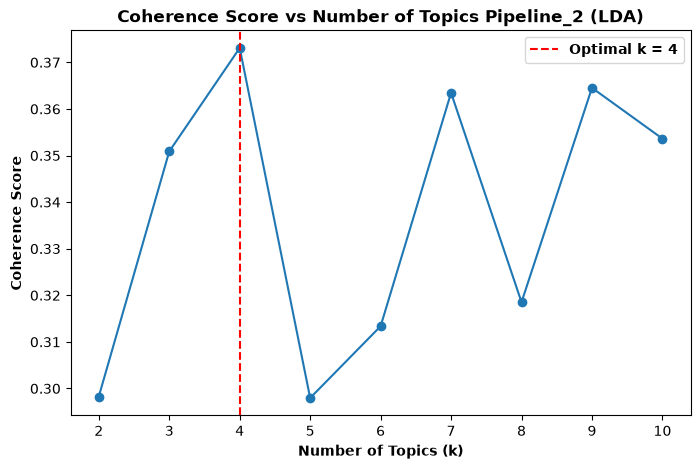

In [6]:
# Block 5

terms = tfidf_vectorizer.get_feature_names_out()
# '.get_feature_names_out()' retrieves the vocabulary terms learned by 'TfidfVectorizer', needed here
# to translate each topic's word indices back into actual terms/words.

dictionary = Dictionary(cleaned_tokens)
# 'Dictionary' is a class from the gensim.corpora module, builds a gensim dictionary from 
# the cleaned tokens, mapping each unique word to an integer ID.
# This dictionary is required by gensim's 'CoherenceModel' class to compute the coherence score for the
# topics generated by the LDA model.

k_values = list(range(2, 11))
# Test different numbers of topics, from 2 to 10.

coherence_scores = []
# 'k_values = list(range(2, 11))' creates a list of integers from 2 to 10.
# This is the range of k values to be tested in the coherence scores.

display(Markdown("<h3>The output of this block is:</h3>"))

for k in k_values:
    lda_model_k = LatentDirichletAllocation(
        n_components=k,
        learning_method='batch',
        random_state=42
    )
    # Create an LDA model with k topics.
    # 'learning_method=batch' trains the model using the complete dataset.
    # This is suitable for this project because the dataset is fixed and relatively small.
    # 'random_state=42' makes the results reproducible.

    lda_model_k.fit(tfidf_matrix)
    # Train the LDA model using the TF-IDF document-term matrix.

    topic_words = []
    # This list stores the top words from each topic.

    for topic in lda_model_k.components_:
        top_indices = topic.argsort()[::-1][:10]
        # Find the indices of the 10 words with the highest topic weights.

        top_words = [terms[i] for i in top_indices]
        # Convert the word indices into their corresponding vocabulary terms.

        topic_words.append(top_words)
        # Add the top 10 words of the current topic to the list.

    coherence_model = CoherenceModel(
        topics=topic_words,
        texts=cleaned_tokens,
        dictionary=dictionary,
        coherence='c_v'
    )
    # Calculate the 'C_v' (coherence score) for the current LDA model.

    score = coherence_model.get_coherence()
    # Get the coherence score.

    coherence_scores.append(score)
    # Store the score for the current k value.
    
    display(Markdown(f"**k = {k}, coherence score = {score:.4f}**"))
    # Display the coherence score for each tested number of topics.

optimal_k = k_values[coherence_scores.index(max(coherence_scores))]
# Select the k value with the highest coherence score.

display(Markdown(f"**Optimal number of topics (k): {optimal_k}**"))
# Display the selected optimal number of topics (k).


# Plot the coherence scores to show how the optimal k was selected.

plt.figure(figsize=(8, 5))
# Create the figure.

plt.plot(k_values, coherence_scores, marker='o')
# Plot the coherence score for each k value.

plt.axvline(
    x=optimal_k,
    color = 'red',
    linestyle='--',
    label=f'Optimal k = {optimal_k}'
)
# Add a vertical line at the selected optimal k.

plt.xlabel("Number of Topics (k)", fontweight= 'bold')
# Label the x-axis.

plt.ylabel("Coherence Score", fontweight = 'bold')
# Label the y-axis.

plt.title("Coherence Score vs Number of Topics Pipeline_2 (LDA)", fontweight = 'bold')
# Add the plot title.

plt.legend(prop={'weight': 'bold'})
# Display the legend.

plt.show()
# Display the plot.



#### Justification for selecting the optimal k = 4 topics:
The coherence search in step 5 produced the following results across the tested range:

| k | Coherence Score |

| 2 | 0.2983 |

| 3 | 0.3509 |

| 4 | 0.3731 |

| 5 | 0.2980 |

| 6 | 0.3134 |

    .
    
    .
    
    .
    
    .
    
 We can notice that the score reach at the peak at k = 4, as displayed in the plot graph, 
 then it decreases as the k value increases.



### Step 6 : Refit the Final LDA Model and Extract Top Words per Topic

With the optimal number of topics (k= 4) determined and justified in the previous step, 
the final LDA model is fit again with the optimal number of topics to extract the final topics.
Replacing the placeholder value built in step 4 for demonstration purposes only.
This one will now be used for the remainder of this analysis.

For each of the 4 topics, the top words are extracted from 'LatentDirichletAllocation's components_' attribute,
which hold, for every topic, a weight for each vocabulary word that represents how strongly that
word is associated with the topic.
Sorting these weights in descending order and selecting the highest-weighted words identifies the terms/words that
define each topic most strongly, and allows the topics to be interpreted in terms of the actual municipal
issues they represent.



In [8]:
# Block 6

final_lda_model = LatentDirichletAllocation(n_components=optimal_k, learning_method = 'batch', random_state=42)
final_lda_matrix = final_lda_model.fit_transform(tfidf_matrix)
# Refit the final LDA model using the optimal_k found and justified in the previous step.
# Replacing the placeholder value with 'optimal_k' in the 'LatentDirichletAllocation' class.

top_words_per_topic = []
# This opened list wil store the top words for each topic we will loop through it next.

display(Markdown("<h3>The output of this block is:</h3>"))

for topic_idx, topic in enumerate(final_lda_model.components_):
    top_indices = topic.argsort()[::-1][:10]
    top_words = [terms[i] for i in top_indices]
    top_words_per_topic.append(top_words)
    # 'top_indices' returns the top 10 words in each topic.
    # 'terms[i]' translates each topic word index back into the corresponding term/word.
    # 'top_words_per_topic.append(top_words)' appends each topic's words to the list.
    display(Markdown(f"**Topic {topic_idx}:** [{', '.join(top_words)}]"))
    # This print statement will display the top words for each topic.

<h3>The output of this block is:</h3>

**Topic 0:** [dumped, behind, leaking, dumping, lot, main, illegal, old, hydrant, night]

**Topic 1:** [safety, storm, noise, concerned, im, garbage, please, loud, streetlight, really]

**Topic 2:** [near, water, pothole, sidewalk, please, car, leak, stop, bus, entrance]

**Topic 3:** [bin, overflowing, public, right, park, streetlight, fire, trash, attracting, pothole]


### Step 7: Calculate Topic Prevalence

With the topics extracted and interpreted, this step measures how prevalent each topic is
across the whole corpus, as specified in the project workflow chart.
This step tells us not just what the topics are, but also how often each one occurs among the municipal complaints, 
which is essential information for the project's objectives (helping the decision-makers identify which problems occur most
often, and prioritizing their responses accordingly).

Each row in 'final_lda_matrix' represents one complaint as a probability distribution across the 4 topics.
For every complaint, the topic with the highest probability is assigned as that complaint's dominant topic. 
Topic prevalence is then calculated as the proportion of complaints for which each topic is the dominant topic.



In [9]:
# Block 7

dominant_topic = final_lda_matrix.argmax(axis = 1)
# For each complaint, find which topic it has the highest probability for.
# 'final_lda_matrix' has one row per complaint and one column per topic, 
# so 'argmax(axis = 1)' returns, for every row, the column index (topic number)
# with the highest probability value (each complaint's dominant topic).

topic_prevalence = pd.Series(dominant_topic).value_counts(normalize = True).sort_index()
# Count how many complaints have each topic as their dominant topic, and convert these counts into proportions.
# So the result reads as a percentage of the whole corpus.
# 'sort_index()' orders the result by topic number for easier reading.

display(Markdown("<h3>The output of this block is:</h3>"))
# Display a larger heading above the output.

for topic_idx, proportion in topic_prevalence.items():
    display(Markdown(f"**Topic {topic_idx}:** {proportion:.2%} of complaints"))
# Display the prevalence of each topic as a percentage of the whole corpus.


<h3>The output of this block is:</h3>

**Topic 0:** 19.24% of complaints

**Topic 1:** 34.45% of complaints

**Topic 2:** 29.75% of complaints

**Topic 3:** 16.55% of complaints


### Step 8: Rank the Topics Based on Topic Prevalence

The final step of this pipeline is to rank the topics based on their prevalence percentages, 
producing a ranked list of the most frequent and relevant topics as the expected outcome in the project's
conception phase.
This ranking, combined with each topic's top words from step 6, allows municipal decision-makers to see
directly which type of complaint occurs most often, supporting them in prioritizing their responses accordingly.

As in pipeline_1, the code below works for any number of topics, so it does not depend on any
specific value of (k) chosen in pipeline_2.



In [10]:
# Block 8

topic_ranking = topic_prevalence.sort_values(ascending= False)
# Sort topics by their prevalence percentages in descending order, so the most common topic appears first.

display(Markdown("<h3>The output of this block is:</h3>"))

display(Markdown("**Ranked Topics - Pipeline_2 (LDA) Model**"))

for rank, (topic_idx, proportion) in enumerate(topic_ranking.items(), start = 1):
    display(Markdown(f"**- Rank {rank}: Topic {topic_idx} ({proportion:.2%} of complaints)**"))
    display(Markdown(f"**- Top words:** {top_words_per_topic[topic_idx]}"))
# Display the final ranked list, combining each topic's rank with its prevalence and its top words,
# so the result is a single, readable summary of the most frequent complaint categories.
# This directly supports municipal decision-makers in prioritizing their responses accordingly.


<h3>The output of this block is:</h3>

**Ranked Topics - Pipeline_2 (LDA) Model**

**- Rank 1: Topic 1 (34.45% of complaints)**

**- Top words:** ['safety', 'storm', 'noise', 'concerned', 'im', 'garbage', 'please', 'loud', 'streetlight', 'really']

**- Rank 2: Topic 2 (29.75% of complaints)**

**- Top words:** ['near', 'water', 'pothole', 'sidewalk', 'please', 'car', 'leak', 'stop', 'bus', 'entrance']

**- Rank 3: Topic 0 (19.24% of complaints)**

**- Top words:** ['dumped', 'behind', 'leaking', 'dumping', 'lot', 'main', 'illegal', 'old', 'hydrant', 'night']

**- Rank 4: Topic 3 (16.55% of complaints)**

**- Top words:** ['bin', 'overflowing', 'public', 'right', 'park', 'streetlight', 'fire', 'trash', 'attracting', 'pothole']


### Step 9 : Summary of Pipeline 2 (LDA)


This pipeline analyzed the same 447 unique, preprocessed municipal complaints used in Pipeline_1,
loaded directly from `preprocessed_complaints.csv` to guarantee both pipelines work on identical data.
The complaint text was converted into a TF-IDF document-term matrix of 447 documents across a
vocabulary of 747 unique terms, using `TfidfVectorizer`.

Latent Dirichlet Allocation (`LatentDirichletAllocation`) was applied as a test to this matrix.
Then, the optimal number of topics `k` was determined using coherence scores (`gensim.models.CoherenceModel`) imported from 'gensim', tested across
`k=2 to k=10`, a range chosen based on the volume of this dataset, since it is not a large dataset, to ensure each topic remains supported
by a statistically defensible number of documents. Within this range, k=4 produced the highest
coherence score (0.373) as an interior peak of the plot graph, scoring higher than both its immediate neighbors
(`k=3: 0.351, k=5: 0.298`).

The final model `LDA` with its optimal `k`, refit with `k=4`, produced four topics with noticeably clearer thematic separation than
the two overlapping topics found in Pipeline_1.
Topic prevalence showed a more balanced distribution across all four topics, with no single topic dominating the corpus. 
The ranked list of topics, with their human-readable labels based on their top words, is presented below:

**Rank 1:** Topic 1 — 34.45% — Public Safety and Noise Disturbances

**Rank 2:** Topic 2 — 29.75% — Road Infrastructure and Water Leaks

**Rank 3:** Topic 0 — 19.24% — Illegal Dumping and Water Infrastructure

**Rank 4:** Topic 3 — 16.55% — Waste Management and Public Spaces

This ranked list directly addresses the project's stated goal: providing municipal decision-makers with
a clear, evidence-based overview of which complaint categories occur most frequently, so they can
prioritize their responses accordingly.
The most pressing concern reported by residents, accounting for over one-third of all complaints,
relates to public safety, noise disturbances, and inadequate street lighting.
Road infrastructure damage and water leaks account for nearly a third of complaints, followed
by illegal dumping and water infrastructure issues, and waste management and public space deterioration.

Overall, Pipeline_2 produced more interpretable and actionable results than Pipeline_1 for this
dataset, both in terms of topic separation and prevalence balance.

This finding and its implications for the comparison between the two pipelines are discussed in the final section.
